# 035. 네이버 영화평 감성 분류

- 한글 형태소 분석기 Okt 사용 전처리  

- Keras Tokenizer, pad_sequences 함수 사용

In [2]:
import numpy as np
import pandas as pd
import re
import time

from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [6]:
DATA_TRAIN_PATH = tf.keras.utils.get_file("ratings_train.txt", 
                                "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_train.txt")
DATA_TEST_PATH = tf.keras.utils.get_file("ratings_test.txt", 
                                "https://github.com/ironmanciti/NLP_lecture/raw/master/data/naver_movie/ratings_test.txt")

14630912/14628807 [==============================] - 2s 0us/step


In [7]:
# DATA_TRAIN_PATH = './data/naver_movie/ratings_train.txt'
# DATA_TEST_PATH = './data/naver_movie/ratings_test.txt'

train_data = pd.read_csv(DATA_TRAIN_PATH, delimiter='\t', quoting=3)
train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


**null value 제거**

In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


In [4]:
train_data.dropna(inplace=True)

In [5]:
test_data = pd.read_csv(DATA_TEST_PATH, delimiter='\t', quoting=3)
test_data.head()

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [6]:
test_data.dropna(inplace=True)

**한글 문자가 아닌 것 모두 제거**

In [7]:
okt = Okt()
test = "아버지가방에들어가신다"
okt.morphs(test)

['아버지', '가방', '에', '들어가신다']

## Text Data 전처리

In [8]:
def preprocessing(sentence, remove_stopwords=True):
    # 불용어 제거
    stop_words = set(['에', '은', '는', '이', '가', '그리고', '것', '들', '수', '등', '로', '을', '를', '만', '도', '아', '의', '그', '다'])
    
    sentence = re.sub('\\\\n', ' ', sentence)              # 개행문자 제거
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', "", sentence)  #한글외에 모두 제거
    sentence = okt.morphs(sentence, stem=True)
    if remove_stopwords:
        sentence = [token for token in sentence if not token in stop_words]
    return sentence

In [9]:
clean_train = []
train_labels = []
clean_test = []
test_labels = []

start = time.time()

for i, (sent, label) in enumerate(zip(train_data['document'], train_data['label'])):
    if i % 10000 == 0:
        print(f"processed = {i}")
    sent = preprocessing(sent)
    if len(sent) > 0:
        clean_train.append(sent)
        train_labels.append(label)

for i, (sent, label) in enumerate(zip(test_data['document'], test_data['label'])):
    if i % 10000 == 0:
        print(f"processed = {i}")
    sent = preprocessing(sent)
    if len(sent) > 0:
        clean_test.append(sent)
        test_labels.append(label)
    
print(time.time() - start)

processed = 0
processed = 10000
processed = 20000
processed = 30000
processed = 40000
processed = 50000
processed = 60000
processed = 70000
processed = 80000
processed = 90000
processed = 100000
processed = 110000
processed = 120000
processed = 130000
processed = 140000
processed = 0
processed = 10000
processed = 20000
processed = 30000
processed = 40000
450.6780972480774


In [10]:
print(len(clean_train))
print(len(train_labels))
print(len(clean_test))
print(len(test_labels))

148718
148718
49566
49566


In [11]:
VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(clean_train)

train_sequences = tokenizer.texts_to_sequences(clean_train)
test_sequences = tokenizer.texts_to_sequences(clean_test)

In [12]:
word_index = tokenizer.word_index
len(word_index)

43752

In [13]:
print(train_sequences[:5])
print()
print(test_sequences[:5])

[[458, 16, 259, 660], [919, 460, 40, 599, 2, 213, 1455, 25, 965, 676, 19], [387, 2452, 1, 2319, 5676, 3, 220, 11], [6500, 105, 8133, 218, 55, 5, 26, 3617], [1025, 19425, 9156, 25, 832, 2, 2586, 21, 1111, 238, 4, 14255, 19426, 1079, 253, 238]]

[[644, 87], [58, 163, 26, 430, 19, 20, 297, 882, 45, 785, 18], [67, 19, 86, 338, 110, 104, 61, 148, 275], [18, 123, 2221, 102, 61, 35, 24, 193, 13775, 801, 4], [209, 2922, 13, 27, 209, 2]]


평균 문장 길이를 기준으로 padding

In [14]:
MAX_SEQUENCE_LENGTH = np.mean([len(sent) for sent in train_sequences], dtype=int)
MAX_SEQUENCE_LENGTH 

10

In [15]:
train_inputs = pad_sequences(train_sequences, 
                                             maxlen=MAX_SEQUENCE_LENGTH,
                                             padding='post')
train_labels = np.array(train_labels)

test_inputs = pad_sequences(test_sequences, 
                                             maxlen=MAX_SEQUENCE_LENGTH,
                                             padding='post')
test_labels = np.array(test_labels)

print(len(train_inputs))
print(len(train_labels))
print(len(test_inputs))
print(len(test_labels))

148718
148718
49566
49566


In [16]:
print(train_inputs[:5])
print()
print(test_inputs[:5])

[[  458    16   259   660     0     0     0     0     0     0]
 [  460    40   599     2   213  1455    25   965   676    19]
 [  387  2452     1  2319  5676     3   220    11     0     0]
 [ 6500   105  8133   218    55     5    26  3617     0     0]
 [ 2586    21  1111   238     4 14255 19426  1079   253   238]]

[[  644    87     0     0     0     0     0     0     0     0]
 [  163    26   430    19    20   297   882    45   785    18]
 [   67    19    86   338   110   104    61   148   275     0]
 [  123  2221   102    61    35    24   193 13775   801     4]
 [  209  2922    13    27   209     2     0     0     0     0]]


### sequence 를 다시 문장으로 역변환

In [17]:
reverse_word_index = dict([(v, k) for (k, v) in word_index.items()])

def decode_sentence(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])

print(decode_sentence(train_inputs[0]))

더빙 진짜 짜증나다 목소리 ? ? ? ? ? ?


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM

model = Sequential([
    Embedding(VOCAB_SIZE+1, 64),
    Bidirectional(LSTM(64)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 64)          1280064   
_________________________________________________________________
bidirectional (Bidirectional (None, 128)               66048     
_________________________________________________________________
dense (Dense)                (None, 32)                4128      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 33        
Total params: 1,350,273
Trainable params: 1,350,273
Non-trainable params: 0
_________________________________________________________________


In [19]:
num_epochs = 5
history = model.fit(train_inputs, train_labels, epochs=num_epochs,
                           batch_size=128, validation_data=(test_inputs, test_labels),
                           verbose=1)

Train on 148718 samples, validate on 49566 samples
Epoch 1/5
148718/148718 [==============================] - 35s 233us/sample - loss: 0.4052 - accuracy: 0.8129 - val_loss: 0.3776 - val_accuracy: 0.8288
Epoch 2/5
148718/148718 [==============================] - 28s 190us/sample - loss: 0.3289 - accuracy: 0.8539 - val_loss: 0.3744 - val_accuracy: 0.8333
Epoch 3/5
148718/148718 [==============================] - 28s 190us/sample - loss: 0.2863 - accuracy: 0.8743 - val_loss: 0.3972 - val_accuracy: 0.8295
Epoch 4/5
148718/148718 [==============================] - 28s 189us/sample - loss: 0.2494 - accuracy: 0.8928 - val_loss: 0.4346 - val_accuracy: 0.8313
Epoch 5/5
148718/148718 [==============================] - 29s 194us/sample - loss: 0.2174 - accuracy: 0.9084 - val_loss: 0.4650 - val_accuracy: 0.8226


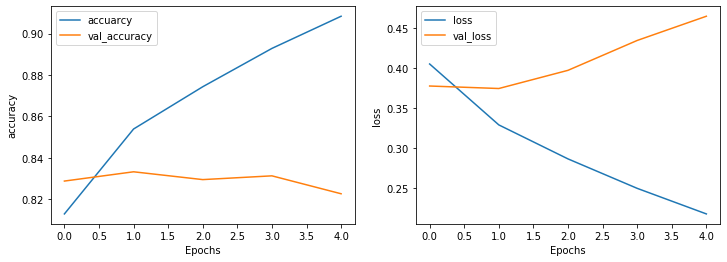

In [20]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['accuarcy', 'val_accuracy'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('loss')
ax2.legend(['loss', 'val_loss'])
plt.show()

In [21]:
sample_text = ['이 영화는 정말 짜증나서 못 보겠다']
#sample_text = ['이렇게 감동적인 영화는 정말 간만이다']
sample_seq = tokenizer.texts_to_sequences(sample_text)
sample_padded = pad_sequences(sample_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
sample_padded

array([[ 1,  1, 10,  1, 34,  1,  0,  0,  0,  0]])

In [22]:
model.predict([sample_padded])

array([[0.51079404]], dtype=float32)

In [23]:
model.layers

## Embedding Layer 시각화

- Embedding projector https://projector.tensorflow.org/  를 이용하여 word embedding 시각화

In [24]:
e = model.layers[0]
weights = e.get_weights()[0]
print(weights.shape)

(20001, 64)


### embedding layer 의 weight 를 disk 에 write. Embedding projector 사용을 위해 embedding vector file 과 단어가 들어 있는 meta data file 로 구분하여 upload.

In [27]:
import io

out_v = io.open('./data/vects.tsv', 'w', encoding='utf-8')
out_m = io.open('./data/meta.tsv', 'w', encoding='utf-8')

for i in range(1, 1000):
    word = tokenizer.index_word.get(i, '?')
    embeddings = weights[i]
    out_m.write(word + '\n')
    out_v.write('\t'.join([str(x) for x in embeddings]) + '\n')
    
out_v.close()
out_m.close()

## Embedding 결과 확인

[Embedding Projector](https://projector.tensorflow.org) 에 접속하여 embedding 의 품질 확인